# OMI Real Estate Quotations — Exploratory Analysis

This notebook builds a reproducible analytical dataset from the semiannual **OMI (Osservatorio del Mercato Immobiliare)** quotations published by the *Agenzia delle Entrate*.

**Source:** Agenzia delle Entrate — Osservatorio del Mercato Immobiliare.


## 1. Setup

The notebook keeps the analytical stack lightweight: `pandas` for data preparation, `numpy` for numerical transformations and `matplotlib` for visualization. The project root is resolved from the notebook location so the code does not depend on a specific working directory.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'quotations'

## 2. Load and consolidate the raw OMI releases

OMI quotations are supplied as one semicolon-separated CSV per semester. Each file is loaded independently so that unexpected files can be identified early and the reference period is retained explicitly.


## 3. Initial dataset inspection

Inspect the schema, temporal coverage and raw structure before changing any values.


In [2]:
omi = pd.read_parquet(
    PROJECT_ROOT / "data" / "processed" / "omi_quotations.parquet"
)

print(f"Number of rows: {omi.shape[0]}")
omi.head()

Number of rows: 7516495


,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,reference_year,reference_semester,reference_period,reference_date,Compr_mid,Loc_mid,Compr_spread,Loc_spread,Compr_spread_pct,Loc_spread_pct
0,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,395.0,NaN,150.0,NaN,37.974684,NaN
1,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
2,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
3,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,210.0,1.0,80.0,NaN,38.095238,NaN
4,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,85.0,NaN,30.0,NaN,35.294118,NaN


## 4. Data Exploration


<Axes: xlabel='Descr_Tipologia'>

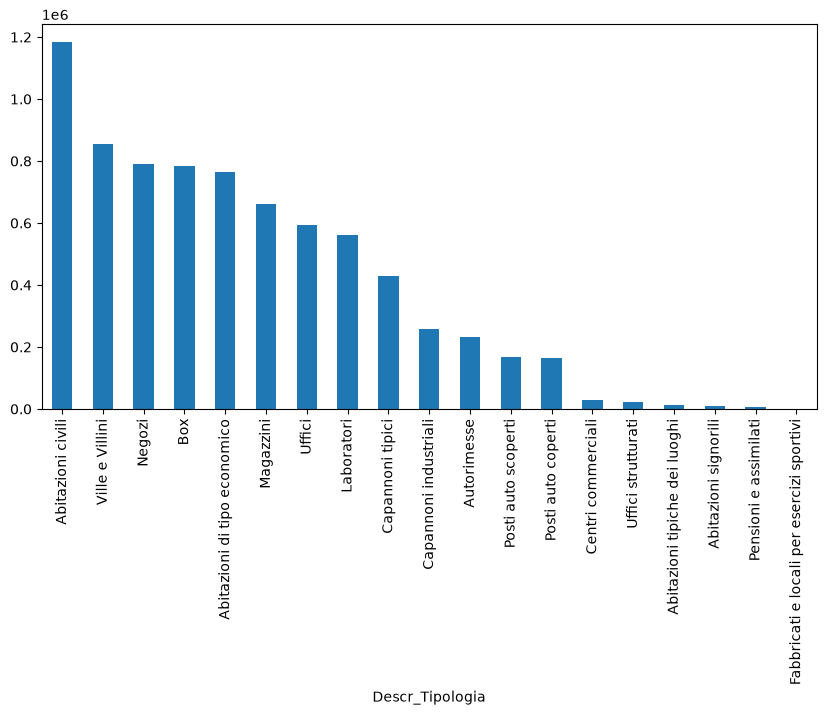

In [4]:
omi["Descr_Tipologia"].value_counts().plot(kind="bar", figsize=(10, 5))

### Residential property descriptions

In [6]:
residential_mask = omi['Descr_Tipologia'].astype('string').str.contains('abitazion|villa', case=False, na=False)
residential = omi.loc[residential_mask].copy()
print(f'Residential observations: {len(residential):,}')

Residential observations: 1,971,694


#### National Trend

In [7]:
national_trend = (
    residential.groupby('reference_date', as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(national_trend.tail(10))

,reference_date,median_compr_mid,mean_compr_mid,observations
34,2021-06-30,900.0,1080.316487,44599
35,2021-12-31,895.0,1081.018900,44710
36,2022-06-30,890.0,1083.308378,44713
37,2022-12-31,890.0,1088.194786,44726
38,2023-06-30,890.0,1092.699031,44767
39,2023-12-31,890.0,1096.451330,44802
40,2024-06-30,890.0,1098.853808,44722
41,2024-12-31,890.0,1105.372006,44428
42,2025-06-30,895.0,1112.899143,44439
43,2025-12-31,900.0,1121.847017,44446


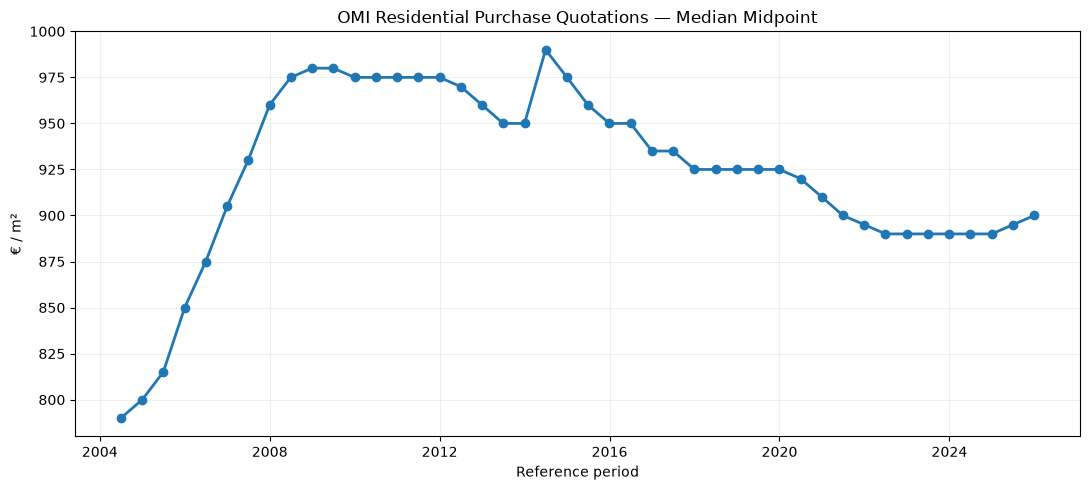

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national_trend['reference_date'], national_trend['median_compr_mid'], marker='o', linewidth=2)
ax.set_title('OMI Residential Purchase Quotations — Median Midpoint')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

#### Regional Inspection

A portfolio analysis should not stop at a national average. Regional market levels are compared at the latest available period, with the aggregation logic shown explicitly.


In [9]:
latest_date = residential['reference_date'].max()
latest_regional = (
    residential.loc[residential['reference_date'].eq(latest_date)]
    .groupby('Regione', as_index=False)
    .agg(median_price_m2=('Compr_mid','median'), observations=('Compr_mid','count'), municipalities=('Comune_ISTAT','nunique'))
    .sort_values('median_price_m2', ascending=False)
)
display(latest_regional.head(15))

,Regione,median_price_m2,observations,municipalities
16,TRENTINO-ALTO ADIGE,2150.0,1645,282
7,LIGURIA,1500.0,1658,234
18,VALLE D'AOSTA/VALLE`E D'AOSTE,1275.0,480,74
15,TOSCANA,1250.0,1911,272
19,VENETO,1125.0,3178,561
8,LOMBARDIA,1125.0,7182,1500
4,EMILIA-ROMAGNA,1100.0,2767,330
6,LAZIO,1050.0,2161,378
9,MARCHE,905.0,2166,224
12,PUGLIA,765.0,1659,254


##### Top 10

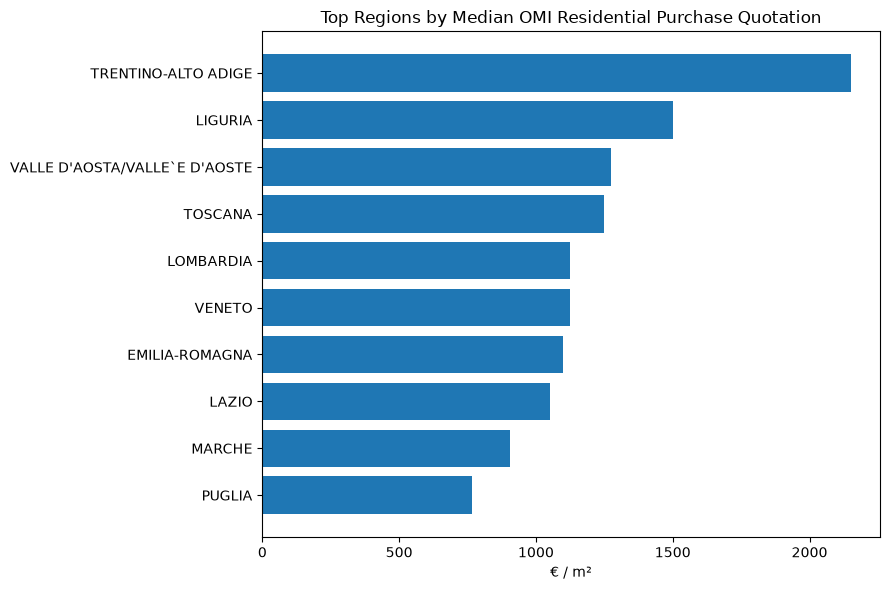

In [10]:
top_regions = latest_regional.head(10).sort_values('median_price_m2')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_regions['Regione'], top_regions['median_price_m2'])
ax.set_title('Top Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')
fig.tight_layout()
plt.show()

##### Trend top 10

In [19]:
regional_trend = (
    residential.groupby(['reference_date', "Regione"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(regional_trend.tail(10))

,reference_date,Regione,median_compr_mid,mean_compr_mid,observations
870,2025-12-31,MOLISE,425.0,504.259962,527
871,2025-12-31,PIEMONTE,765.0,890.331683,4545
872,2025-12-31,PUGLIA,765.0,900.528933,1659
873,2025-12-31,SARDEGNA,725.0,997.329218,1215
874,2025-12-31,SICILIA,570.0,667.050095,2645
875,2025-12-31,TOSCANA,1250.0,1431.282051,1911
876,2025-12-31,TRENTINO-ALTO ADIGE,2150.0,2370.805471,1645
877,2025-12-31,UMBRIA,700.0,710.474482,627
878,2025-12-31,VALLE D'AOSTA/VALLE`E D'AOSTE,1275.0,1652.770833,480
879,2025-12-31,VENETO,1125.0,1246.821901,3178


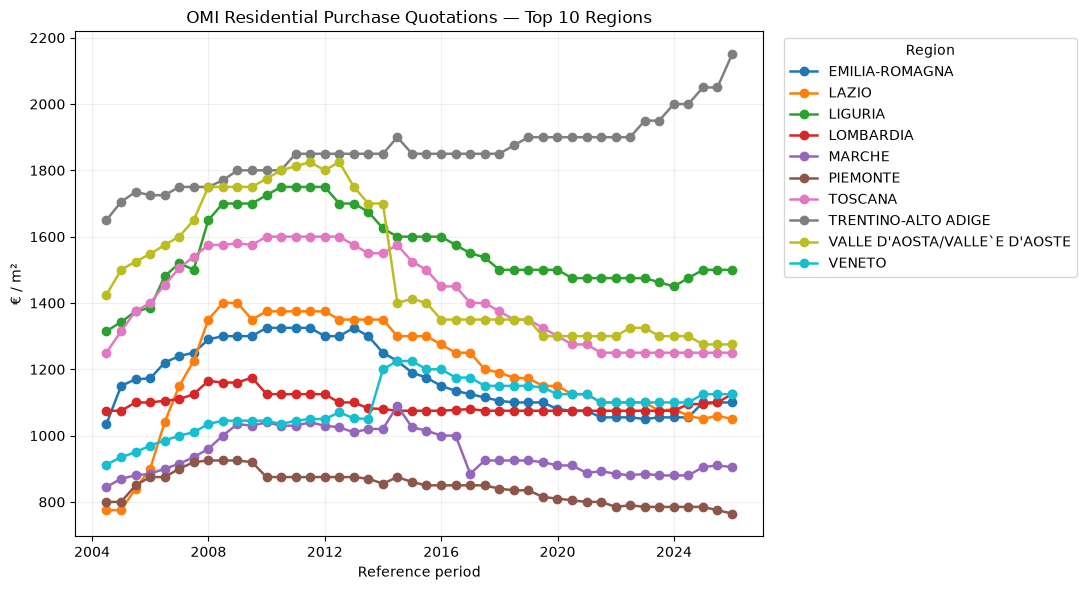

In [22]:
latest_date = regional_trend['reference_date'].max()

top_regions = (
    regional_trend[regional_trend['reference_date'].eq(latest_date)]
    .nlargest(10, 'median_compr_mid')['Regione']
)

plot_data = regional_trend[
    regional_trend['Regione'].isin(top_regions)
]

fig, ax = plt.subplots(figsize=(11, 6))

for regione, data in plot_data.groupby('Regione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.8,
        label=regione
    )

ax.set_title('OMI Residential Purchase Quotations — Top 10 Regions')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)
ax.legend(
    title='Region',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

#### Proviencial Inspection

In [23]:
latest_prov = (
    residential.loc[residential['reference_date'].eq(latest_date)]
    .groupby('Prov', as_index=False)
    .agg(median_price_m2=('Compr_mid','median'), observations=('Compr_mid','count'), municipalities=('Comune_ISTAT','nunique'))
    .sort_values('median_price_m2', ascending=False)
)
display(latest_prov.head(15))

,Prov,median_price_m2,observations,municipalities
17,BZ,2550.0,713,116
84,SV,2250.0,366,69
49,MI,1800.0,1048,188
87,TN,1800.0,932,166
32,FI,1800.0,281,41
43,LI,1775.0,147,19
75,RM,1675.0,903,121
91,TS,1650.0,45,6
38,IM,1625.0,516,66
14,BO,1550.0,719,55


##### Top 10

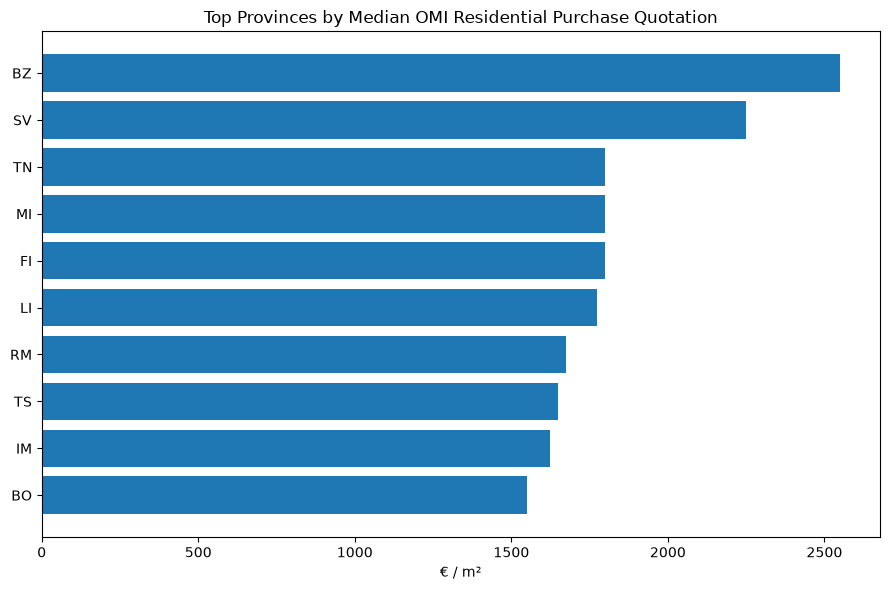

In [24]:
top_prov = latest_prov.head(10).sort_values('median_price_m2')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_prov['Prov'], top_prov['median_price_m2'])
ax.set_title('Top Provinces by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')
fig.tight_layout()
plt.show()

In [25]:
provincial_trend = (
    residential.groupby(['reference_date', "Prov"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(provincial_trend.tail(10))

,reference_date,Prov,median_compr_mid,mean_compr_mid,observations
4478,2025-12-31,TV,1150.00,1207.291221,467
4479,2025-12-31,UD,775.00,820.537736,530
4480,2025-12-31,VA,1200.00,1262.097458,472
4481,2025-12-31,VB,925.00,999.872774,393
4482,2025-12-31,VC,645.00,748.481675,191
4483,2025-12-31,VE,1250.00,1558.449304,503
4484,2025-12-31,VI,1150.00,1142.216809,821
4485,2025-12-31,VR,1177.50,1434.568750,400
4486,2025-12-31,VT,925.00,971.548117,239
4487,2025-12-31,VV,411.25,489.698795,166


##### Trend top 10

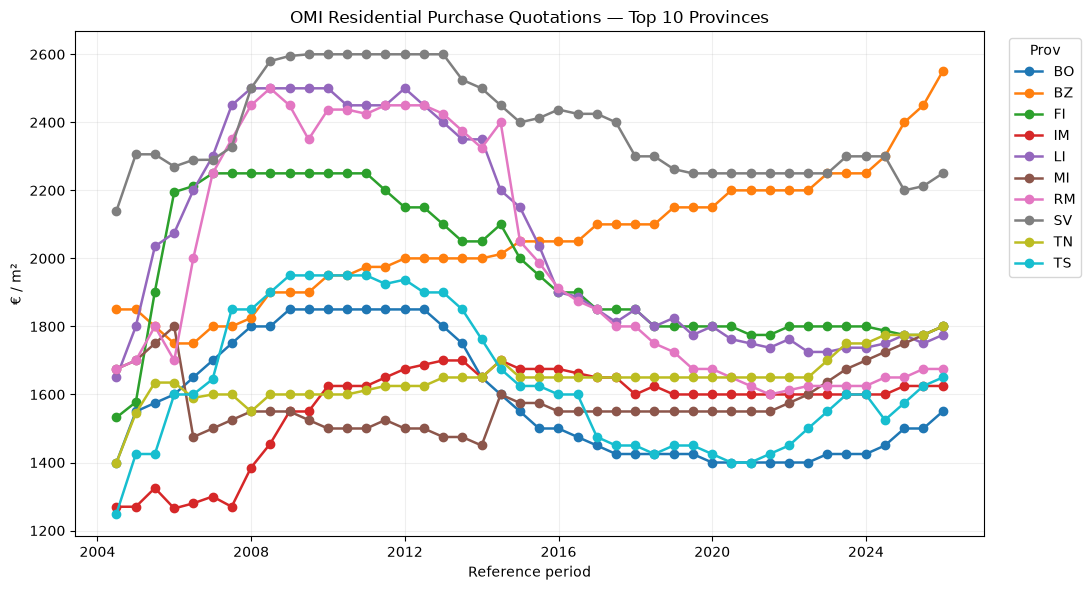

In [27]:
latest_date = provincial_trend['reference_date'].max()

top_prov = (
    provincial_trend[provincial_trend['reference_date'].eq(latest_date)]
    .nlargest(10, 'median_compr_mid')['Prov']
)

plot_data = provincial_trend[
    provincial_trend['Prov'].isin(top_prov)
]

fig, ax = plt.subplots(figsize=(11, 6))

for prov, data in plot_data.groupby('Prov'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.8,
        label=prov
    )

ax.set_title('OMI Residential Purchase Quotations — Top 10 Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)
ax.legend(
    title='Prov',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

#### Comununal Inspection

##### Top 10

In [15]:
latest_comu = (
    residential.loc[residential['reference_date'].eq(latest_date)]
    .groupby('Comune_descrizione', as_index=False)
    .agg(median_price_m2=('Compr_mid','median'), observations=('Compr_mid','count'), municipalities=('Comune_ISTAT','nunique'))
    .sort_values('median_price_m2', ascending=False)
)
display(latest_comu.head(15))

,Comune_descrizione,median_price_m2,observations,municipalities
5328,PORTOFINO,8850.0,7,1
2350,CORTINA D`AMPEZZO,8825.0,4,1
2389,COURMAYEUR,7325.0,16,1
6606,SELVA DI VAL GARDENA .WOLKENSTEIN IN GROEDEN.,6900.0,8,1
4701,ORTISEI .SANKT ULRICH.,6825.0,8,1
1294,CAPRI,6150.0,9,1
1202,CANAZEI,5650.0,2,1
440,BADIA .ABTEI.,5250.0,6,1
221,ANACAPRI,5175.0,4,1
5129,PINZOLO,4850.0,17,1


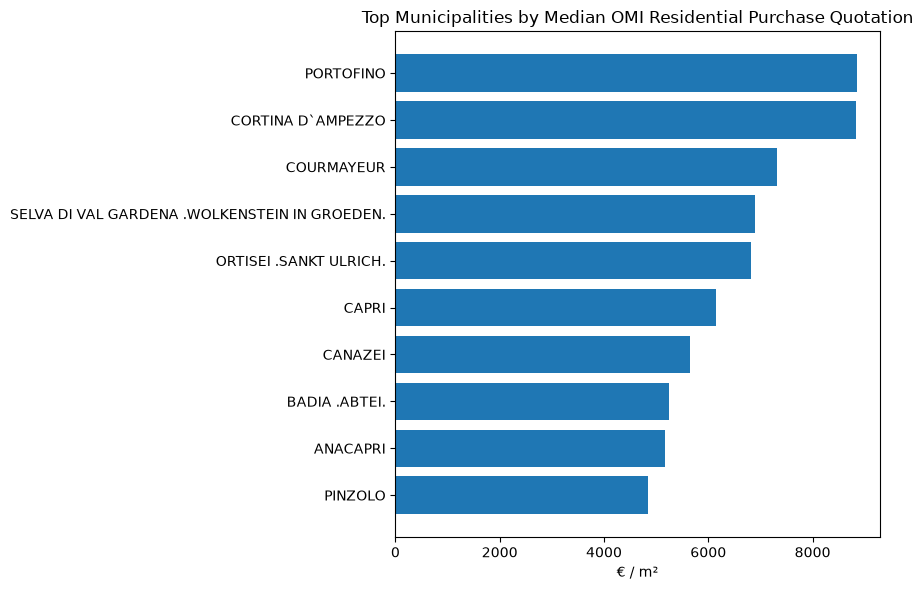

In [16]:
top_comu = latest_comu.head(10).sort_values('median_price_m2')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_comu['Comune_descrizione'], top_comu['median_price_m2'])
ax.set_title('Top Municipalities by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')
fig.tight_layout()
plt.show()

In [28]:
municipal_trend = (
    residential.groupby(['reference_date', "Comune_descrizione"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(municipal_trend.tail(10))

,reference_date,Comune_descrizione,median_compr_mid,mean_compr_mid,observations
352366,2025-12-31,ZOPPOLA,700.00,696.875,8
352367,2025-12-31,ZOVENCEDO,937.50,860.000,4
352368,2025-12-31,ZUBIENA,336.25,358.125,4
352369,2025-12-31,ZUCCARELLO,1425.00,1425.000,1
352370,2025-12-31,ZUGLIANO,1087.50,1096.250,8
352371,2025-12-31,ZUGLIO,545.00,565.000,3
352372,2025-12-31,ZUMAGLIA,347.50,347.500,2
352373,2025-12-31,ZUMPANO,610.00,612.000,5
352374,2025-12-31,ZUNGOLI,451.25,461.250,8
352375,2025-12-31,ZUNGRI,351.25,351.250,2


##### Trend top 10

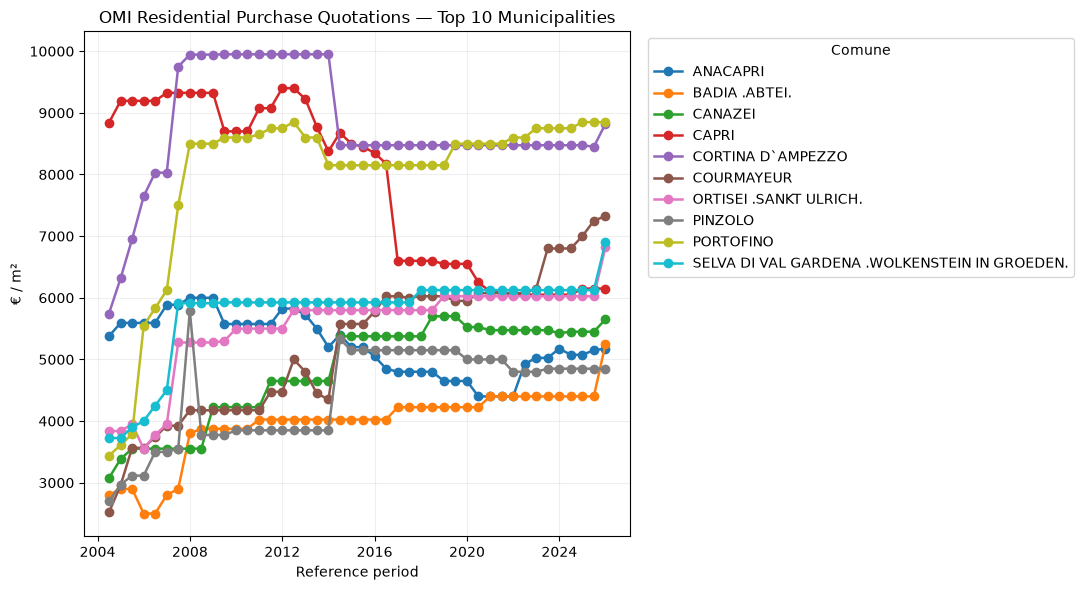

In [29]:
latest_date = municipal_trend['reference_date'].max()

top_municipalities = (
    municipal_trend[municipal_trend['reference_date'].eq(latest_date)]
    .nlargest(10, 'median_compr_mid')['Comune_descrizione']
)

plot_data = municipal_trend[
    municipal_trend['Comune_descrizione'].isin(top_municipalities)
]

fig, ax = plt.subplots(figsize=(11, 6))

for prov, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.8,
        label=prov
    )

ax.set_title('OMI Residential Purchase Quotations — Top 10 Municipalities')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)
ax.legend(
    title='Comune',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()